In [1]:
%load_ext lab_black
%load_ext autoreload
%autoreload 2
%matplotlib inline


In [2]:
from mne_connectivity.viz import plot_connectivity_circle
from mne.viz import circular_layout
import matplotlib.pyplot as plt
import numpy as np
import pickle


In [6]:
def get_channel_5_colors():
    return [
        "AF3",
        "F1",
        "F3",
        "F5",
        "F7",
        "FC1",
        "FC3",
        "FC5",
        "FCZ",
        "FP1",
        "FPZ",
        "FT7",
        "FZ",
        "C1",
        "C3",
        "C5",
        "CZ",
        "T7",
        "CP1",
        "CP3",
        "CP5",
        "CPZ",
        "P1",
        "P3",
        "P5",
        "P7",
        "PZ",
        "PO3",
        "PO5",
        "PO7",
        "POZ",
        "O1",
        "OZ",
        "TP7",
        "TP8",
        "T8",
        "PO8",
        "PO6",
        "PO4",
        "O2",
        "P8",
        "P6",
        "P4",
        "P2",
        "CP6",
        "CP4",
        "CP2",
        "C6",
        "C4",
        "C2",
        "FT8",
        "FP2",
        "FC6",
        "FC4",
        "FC2",
        "F8",
        "F6",
        "F4",
        "F2",
        "AF4",
    ]


def assign_channel_5_colors():
    red = (0.458, 0.0, 0.0, 1.0)
    green = (0.0, 1.0, 0.0, 1.0)
    blue = (0.0, 0.0, 0.999, 1.0)
    purple = (0.5, 0.0, 0.5, 1.0)
    orange = (1.0, 0.647, 0.0, 1.0)
    black = (0.0, 0.0, 0.0, 1.0)

    # New color for separators
    channel_color = {
        # Frontal (Red)
        "AF3": red,
        "AF4": red,
        "F1": red,
        "F2": red,
        "F3": red,
        "F4": red,
        "F5": red,
        "F6": red,
        "F7": red,
        "F8": red,
        "FC1": red,
        "FC2": red,
        "FC3": red,
        "FC4": red,
        "FC5": red,
        "FC6": red,
        "FCZ": red,
        "FP1": red,
        "FP2": red,
        "FPZ": red,
        "FT7": red,
        "FT8": red,
        "FZ": red,
        # Central (Green)
        "C1": green,
        "C2": green,
        "C3": green,
        "C4": green,
        "C5": green,
        "C6": green,
        "CZ": green,
        # Parietal (Blue)
        "CP1": blue,
        "CP2": blue,
        "CP3": blue,
        "CP4": blue,
        "CP5": blue,
        "CP6": blue,
        "CPZ": blue,
        "P1": blue,
        "P2": blue,
        "P3": blue,
        "P4": blue,
        "P5": blue,
        "P6": blue,
        "P7": blue,
        "P8": blue,
        "PZ": blue,
        # Occipital (Purple)
        "O1": purple,
        "O2": purple,
        "OZ": purple,
        "PO3": purple,
        "PO4": purple,
        "PO5": purple,
        "PO6": purple,
        "PO7": purple,
        "PO8": purple,
        "POZ": purple,
        # Temporal (Orange)
        "T7": orange,
        "T8": orange,
        "TP7": orange,
        "TP8": orange,
    }

    return channel_color


def prepare_circular_layout(label_names):
    """
    Prepare the circular layout for the connectivity plot.

    Args:
    label_names (list): List of channel names.

    Returns:
    tuple: Node angles and node order for the circular layout.
    """
    n_channels = len(label_names)
    node_angles = circular_layout(
        label_names,
        label_names,
        start_pos=90,
        group_boundaries=[0, len(label_names) // 2],
    )
    node_order = label_names
    return node_angles, node_order


def get_circular_plot_requirements(label_names):
    """
    Get the requirements for a circular connectivity plot with left channels first.

    Args:
    label_names (list): List of channel names.

    Returns:
    tuple: Node angles, node order, and node colors for the circular plot.
    """

    sorted_channels = get_channel_5_colors()

    # Assign colors to channels
    # channel_color = assign_channel_colors(channels_side, left_color, right_color)
    channel_color = assign_channel_5_colors()

    # Prepare circular layout with sorted channels
    node_angles, _ = prepare_circular_layout(list(channel_color.keys()))

    # Get node colors in the same order as sorted_channels
    node_colors = [channel_color[channel] for channel in sorted_channels]

    return node_angles, sorted_channels, node_colors


def plot_circular_connectivity(
    connectivity,
    stage,
    label_names,
    node_angles,
    node_colors,
    method="wpli",
    is_save=False,
    n_lines=20,
    figsize=(8, 8),
):
    """
    Plot circular connectivity diagram.

    Args:
    connectivity (mne.Connectivity): The connectivity object.
    stage (str): The stage of the experiment (e.g., 'pre', 'during', 'post').
    label_names (list): List of channel names.
    node_angles (dict): Dictionary of node angles for the circular plot.
    node_colors (list): List of colors for each node.
    method (str, optional): Connectivity method used. Defaults to "wpli".
    is_save (bool, optional): Whether to save the figure. Defaults to False.
    n_lines (int, optional): Number of connections to draw. Defaults to 20.
    figsize (tuple, optional): Figure size. Defaults to (8, 8).

    Returns:
    matplotlib.figure.Figure: The created figure.
    """
    # Create figure
    fig, ax = plt.subplots(
        figsize=figsize, facecolor="black", subplot_kw=dict(polar=True)
    )

    if not isinstance(connectivity, np.ndarray):
        connectivity = connectivity.get_data("dense")[:, :, 0]

    if connectivity.ndim == 3:
        connectivity = connectivity[:, :, 0]

    print(f"{len(node_angles) = }")
    print(f"{len(node_colors) = }")

    # Plot connectivity circle
    plot_connectivity_circle(
        con=connectivity,
        node_names=label_names,
        n_lines=n_lines,
        node_angles=node_angles,
        node_colors=node_colors,
        title=f"All-to-All Connectivity {stage} stimuli Condition ({method})",
        ax=ax,
    )

    # Adjust layout
    fig.tight_layout()

    # Save figure if requested
    if is_save:
        filename = f"{method}_{stage}.png"
        fig.savefig(filename, dpi=300)
        print(f"Figure saved as {filename}")

    return fig


(60, 60, 1)
len(node_angles) = 60
len(node_colors) = 60


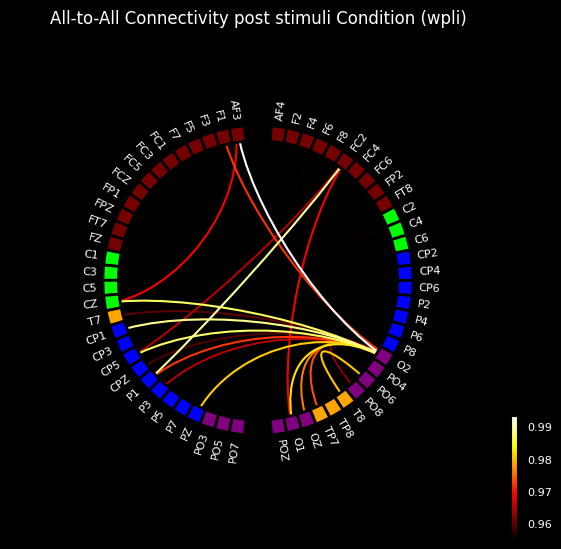

In [7]:
channels = get_channel_5_colors()
node_angles, node_order, node_colors = get_circular_plot_requirements(channels)


con = pickle.load(
    open(
        "D:\\neuro-closeloop-project\\vielight_close_loop\\notebooks\conditions\\1\\results\\2\\2_post_connectivity.pkl",
        "rb",
    )
).get_data("dense")
# Get the shape of the original matrix

print(con.shape)

stage_name = "post"
fig = plot_circular_connectivity(con, stage_name, node_order, node_angles, node_colors)
